In [40]:
import numpy as np
import matplotlib.pyplot as plt
import hcipy as hci

### pupil/ telescope params :
- telescope diam. 
- central obscuration : the diam. of the block in the middle of the pupil
- central obscuration ratio
- spider width : the arms/handles that hold the obscuration in place 
- oversizing factor : 

In [41]:
# physical measurements
telescope_diameter = 8.0       # [m]
central_obscuration = 1.2      # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
spider_width = 0.05            # [m]
# simulation auxillary
oversizing_factor = 16.0 / 15.0
num_pupil_pixels_base = 240
num_pupil_pixels = int(num_pupil_pixels_base * oversizing_factor)  # must be int
pupil_grid_diameter = telescope_diameter * oversizing_factor
pupil_grid = hci.make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)

using the specifications to create the pupil generator :

In [42]:
VLT_aperture_generator = hci.make_obstructed_circular_aperture(
    telescope_diameter,
    central_obscuration_ratio,
    num_spiders=4,
    spider_width=spider_width
)

creating an instance of a pupil :

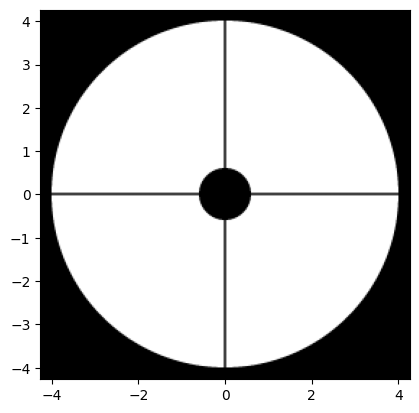

In [43]:
VLT_aperture = hci.evaluate_supersampled(VLT_aperture_generator, pupil_grid, 4)
hci.imshow_field(VLT_aperture,cmap="gray")

setting reference wavelengths of wavefronts for basic simulation :

In [44]:
wavelength_wfs = 0.7e-6   # [m] (not used below, kept for context)
wavelength_sci = 2.2e-6   # [m]

creating the normalized wavefront object which we propagte througe the pupil :

In [45]:
wf = hci.Wavefront(VLT_aperture.copy(), wavelength_sci)
wf.total_power = 1.0  # normalize total power at pupil plane

creating a grid that represents the plane in which the propagation of the wavefront is sampled in discrete pixels :

In [46]:
spatial_resolution = wavelength_sci / telescope_diameter
focal_grid = hci.make_focal_grid(q=4, num_airy=30, spatial_resolution=spatial_resolution)

the propagator object is constructed from the pupil object and the focal grid object, this allows the propagtor to match the output grid to the ratios previously specified.

In [47]:
propagator = hci.FraunhoferPropagator(pupil_grid, focal_grid)

after the wave is passed through the propagator and the output is a field represented as a complex grid, the intensity and power spectrum of the field is calculated :

In [48]:
E_img = propagator.forward(wf)          # complex field
I_img = E_img.power                     # intensity Field on focal_grid (PSF)

C:\Users\yizha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:168: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_multiplications = input_grid.size * output_grid.size
C:\Users\yizha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:169: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_additions = (input_grid.size - 1) * output_grid.size


we shape the intensity np.array as a matrix representing the grid and make sure it makes sense :

In [49]:
I2 = I_img.shaped
ny, nx = focal_grid.shape
assert ny >= 3 and nx >= 3, "Focal grid must be at least 3x3 for a 3x3 bucket."

choosing the pixels that represent the fiber within the pupil.
in these pixels we sum the matching intensity values to get the overall intensity recieved in the channel :

In [50]:
cy, cx = ny // 2, nx // 2
rows = slice(cy - 1, cy + 2)
cols = slice(cx - 1, cx + 2)
mask2 = np.zeros_like(I2, dtype=float)
mask2[rows, cols] = 1.0
bucket_mask = hci.Field(mask2.ravel(), focal_grid)

plot output together :

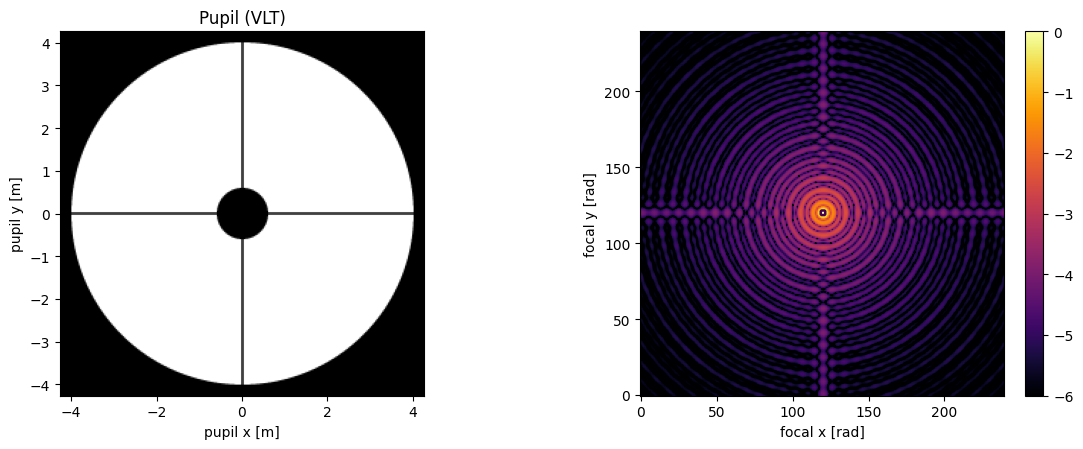

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# Left: pupil
hci.imshow_field(VLT_aperture, cmap='gray', ax=axes[0])
axes[0].set_title('Pupil (VLT)')
axes[0].set_xlabel('pupil x [m]')
axes[0].set_ylabel('pupil y [m]')

# Right: PSF (log10) + 3×3 bucket outline
im1 = axes[1].imshow(np.log10(I2 / I2.max()), origin='lower',cmap='inferno', vmin=-6)
# Overlay the 3×3 boundary as a contour
axes[1].contour(mask2, levels=[0.5], linewidths=1.8)
axes[1].set_xlabel('focal x [rad]')
axes[1].set_ylabel('focal y [rad]')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

plt.show()


In [52]:
I_img = E_img.power              # intensity on focal_grid (PSF), same as |E|^2
I2 = I_img.shaped

ny, nx = focal_grid.shape

assert ny >= 3 and nx >= 3

cy, cx = ny // 2, nx // 2
rows = slice(cy - 1, cy + 2)
cols = slice(cx - 1, cx + 2)

w = focal_grid.weights

In [53]:
mask2 = np.zeros_like(I2, dtype=float)
mask2[rows, cols] = 1.0
bucket_mask = hci.Field(mask2.ravel(), focal_grid)

calculate the total power that remains after propagation :

In [54]:
# Weighted power fraction with scalar/array weight handling
# Uses focal_grid.weights; supports both scalar (uniform grid) and array cases.

w = focal_grid.weights

if np.isscalar(w):
    I_total_weighted = np.sum(I2 * w)
    I_bucket_weighted = np.sum(I2 * mask2 * w)
else:
    w2 = np.asarray(w).reshape(I2.shape)
    I_total_weighted = np.sum(I2 * w2)
    I_bucket_weighted = np.sum(I2 * mask2 * w2)

fraction_weighted = I_bucket_weighted / I_total_weighted

print("Weighted totals (conditional):")
print("I_bucket_weighted =", I_bucket_weighted)
print("I_total_weighted  =", I_total_weighted)
print("fraction_weighted =", fraction_weighted)
print("log10_fraction_weighted =", np.log10(fraction_weighted))


Weighted totals (conditional):
I_bucket_weighted = 1.6422691821733795e-15
I_total_weighted  = 4.6789800384565946e-15
fraction_weighted = 0.3509887130689913
log10_fraction_weighted = -0.45470684914861914


### simulating the propagation within the fiber channel 
we want to simulate the propagation of the recieved amount of the wavefront within the fiber channel.
we will create layers representing the inside of the fiber and propagate the part of the wavefront recieved through the layers.

### creating atmospheric layers 
we want to propagate the wavefront in layers of the atmosphere
for that, we want to create random i.i.d phase screen according to the parameter r0
for this simulation we will propagate it through 100 phase screens with r0 of around ground level (0.15)
the higher r0  => the closer the layer is to simulating a vacuum...

first we specify the parameters of the simulation :

In [55]:
# Ground-layer turbulence via FFT-based Kolmogorov-like phase screen (API-independent)
# Generates a random phase screen with Kolmogorov slope, scales RMS to match r0,
# applies to the pupil wavefront, and compares PSFs.

# 1) Compute r0 at science wavelength
r0_ref_500nm = 0.15   # [m] seeing reference at 500 nm (adjust as needed)
lambda_ref = 500e-9   # [m]
r0_sci = r0_ref_500nm * (wavelength_sci / lambda_ref)**(6.0/5.0)

# 2) FFT-based random phase screen on square grid matching the pupil grid
N = num_pupil_pixels
L = central_obscuration    # [m] total pupil grid span
# L = pupil_grid.diameter    # [m] total pupil grid span
DX = L / N                 # [m] sample spacing in pupil plane


creating the screens randomly :

In [56]:

rng = np.random.default_rng(2025)

fx = np.fft.fftfreq(N, d=DX)   # [cycles/m]
FX, FY = np.meshgrid(fx, fx)
KR = np.sqrt(FX**2 + FY**2)
KR[0, 0] = np.inf  # avoid singularity at zero frequency

# Kolmogorov amplitude spectrum ~ k^{-11/6} (phase PSD ~ k^{-11/3})


mixing the screen with white noise :

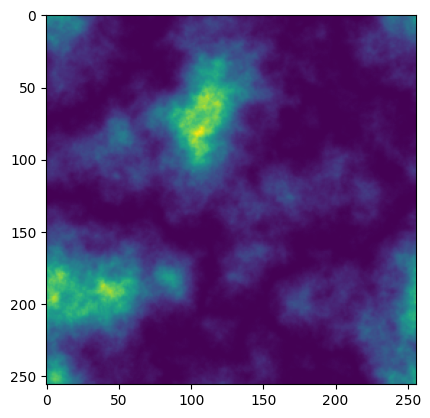

In [57]:
A = KR**(-11.0/6.0)
A[~np.isfinite(A)] = 0.0
# Complex Gaussian white noise
W = (rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))) / np.sqrt(2.0)
S = W * A

phi2 = np.real(np.fft.ifft2(S))
phi2 -= np.mean(phi2)
plt.imshow(np.abs(phi2)**2)

converting it to a scaled hci.field object :

In [58]:
# 3) Scale phase RMS over the pupil to match expected variance ~ 1.03 * (D/r0)^(5/3)
mask = (VLT_aperture.shaped > 0.5)
var_target = 1.03 * (telescope_diameter / r0_sci)**(5.0/3.0)
sigma_target = np.sqrt(var_target)

sigma_curr = np.std(phi2[mask]) if np.any(mask) else np.std(phi2)
if sigma_curr > 0:
    phi2 *= (sigma_target / sigma_curr)

# Wrap as Field on pupil_grid
phi_field = hci.Field(phi2.ravel(), pupil_grid)

propagate the wave through the atmosphere :

In [59]:
# 4) Apply phase and propagate
wf_turb = hci.Wavefront(wf.electric_field.copy(), wavelength_sci)
wf_turb.electric_field *= np.exp(1j * phi_field)

I2_turb = propagator.forward(wf_turb).power.shaped


plot results :

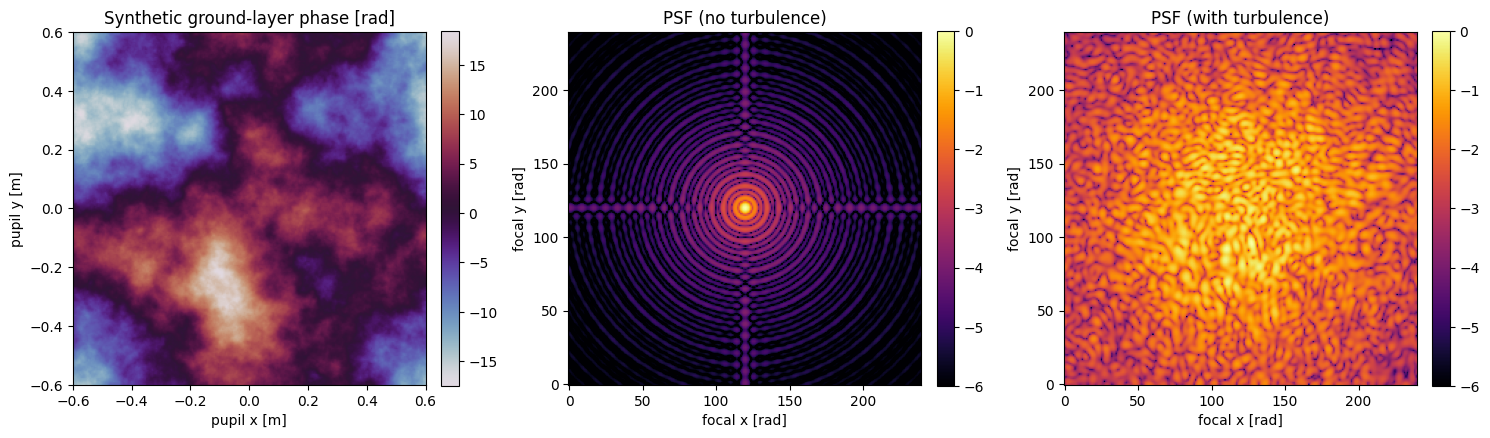

r0: 0.888 m at 2.2 µm; phase RMS over pupil ~ 6.341 rad


In [64]:

# 5) Plot phase and PSFs
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

im0 = axes[0].imshow(phi2, origin='lower', cmap='twilight',extent=[-L/2, L/2, -L/2, L/2])
axes[0].set_title('Synthetic ground-layer phase [rad]')
axes[0].set_xlabel('pupil x [m]')
axes[0].set_ylabel('pupil y [m]')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.log10(I2 / I2.max()), origin='lower', cmap='inferno', vmin=-6)
axes[1].set_title('PSF (no turbulence)')
axes[1].set_xlabel('focal x [rad]')
axes[1].set_ylabel('focal y [rad]')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(np.log10(I2_turb / I2_turb.max()), origin='lower', cmap='inferno', vmin=-6)
axes[2].set_title('PSF (with turbulence)')
axes[2].set_xlabel('focal x [rad]')
axes[2].set_ylabel('focal y [rad]')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

print(f"r0: {r0_sci:.3f} m at {wavelength_sci*1e6:.1f} µm; phase RMS over pupil ~ {np.std(phi2[mask]):.3f} rad")


### simulating the fiber propagation

we choose the specifications, measurements and grids of the the aperture and pupil that we created previously.

In [72]:
um = 1e-6
print(num_pupil_pixels)
D_pupil = 1
print(pupil_grid)
print(VLT_aperture.shape)

256
CartesianGrid(RegularCoords)
(65536,)


we show the internal construct of the fiber and how the propagation will accure within the inner layer/core with high refractive index.
we generate a schematic of an internal slice.

this is not a simulation of any kind but a diagram

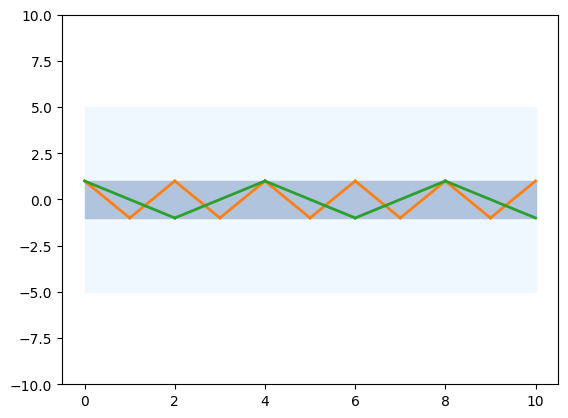

In [79]:
xmax = 10 # x,y bounds
xt=np.linspace(0,xmax) # x,y axes

plt.fill_between(xt,-5,5,color = "aliceblue") # low refractive index shell
plt.fill_between(xt,-1,1,color = "lightsteelblue") # high refractive index core 

x = np.linspace(0, 1)
for i in range(xmax):
    y = (2*(i%2)-1) * 2/(x.max()-x.min()) * (x-x.min()) - (2*(i%2)-1)
    plt.plot(x + i, y, 'C1', linewidth=2)

x = np.linspace(0, 2)
for i in range(5):
    y = (2*(i%2)-1) * 2/(x.max()-x.min()) * (x-x.min()) - (2*(i%2)-1)
    plt.plot(x + 2 * i, y, 'C2', linewidth=2)

plt.ylim([-10,10])
plt.show()

now we construct 2 kinds of fibers :
- multi-mode fiber with a large core that allows higher values of beta as a solution
- single-mode fiber with a small core that allows only a specific value of beta as a solution

this follows the mathematical formula of the number of guided modes allowed :
$$V = \frac{2\pi a}{\lambda} \sqrt{n_1^2 - n_2^2}$$
- $V < 2.405 \longrightarrow $ only  fundemental  mode  allowed  $LP_{01}$ 
- $V > 2.405 \longrightarrow $ multiple modes allowed  $LP_{01} ,LP_{11} ,LP_{12} ... $

In [ ]:
multimode_fiber_core_radius = 25 * um
singlemode_fiber_core_radius = 2 * um

fiber_NA = 0.13
fiber_length = 10

multi_mode_fiber = hci.StepIndexFiber(multimode_fiber_core_radius, fiber_NA, fiber_length)
single_mode_fiber = hci.StepIndexFiber(singlemode_fiber_core_radius, fiber_NA, fiber_length)

we now want to create the focal plane according to the minimal diam. needed which is the largest between the diam. of the fibers : $50\mu m$

In [82]:
num_focal_pixels = num_pupil_pixels
D_focus = 2.1 * multimode_fiber_core_radius
focal_grid = hci.make_pupil_grid(num_focal_pixels, D_focus)

focal_length = D_pupil/(2 * fiber_NA)
propagator = hci.FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)

In [127]:
# wavelength = 500e-9
wavelength = 1550e-9
wf = hci.Wavefront(VLT_aperture, wavelength)
wf.total_power = 1

wf_foc = propagator(wf)

wf_mmf = multi_mode_fiber.forward(wf_foc)
wf_smf = single_mode_fiber.forward(wf_foc)

print("Multi-mode fiber throughput {:g}".format(wf_mmf.total_power))
print("Single-mode fiber throughput {:g}".format(wf_smf.total_power))

C:\Users\yizha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:168: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_multiplications = input_grid.size * output_grid.size
C:\Users\yizha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:169: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_additions = (input_grid.size - 1) * output_grid.size


Multi-mode fiber throughput 1.80818e-06
Single-mode fiber throughput 0.000878668


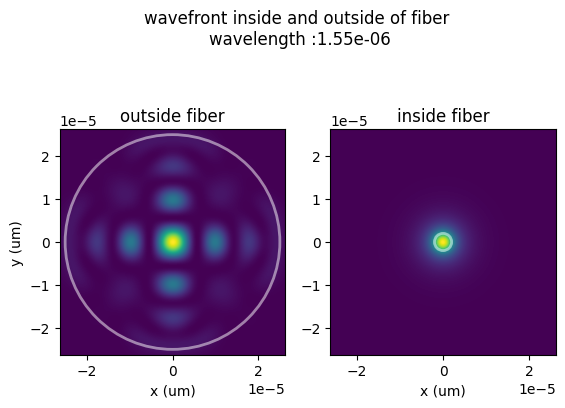

In [128]:
plt.subplot(1,2,1)
hci.imshow_field(wf_mmf.power)
plt.title("outside fiber")
circ = plt.Circle((0, 0), multimode_fiber_core_radius, edgecolor='white', fill=False, linewidth=2, alpha=0.5)
plt.gca().add_artist(circ)
plt.xlabel('x (um)')
plt.ylabel('y (um)')

plt.subplot(1,2,2)
hci.imshow_field(wf_smf.power)
plt.title("inside fiber")
circ = plt.Circle((0, 0), singlemode_fiber_core_radius, edgecolor='white', fill=False, linewidth=2, alpha=0.5)
plt.gca().add_artist(circ)
plt.xlabel('x (um)')

# Save figure to simulation_output
import os
output_dir = 'simulation_output'
os.makedirs(output_dir, exist_ok=True)
fig = plt.gcf()
fig.savefig(os.path.join(output_dir, f'fiber_wavefront_plot_{wavelength}.png'), dpi=300, bbox_inches='tight')

plt.suptitle(f"wavefront inside and outside of fiber \nwavelength :{wavelength}")
plt.show()